In [ ]:
#pip install keras

In [ ]:
from keras.utils import to_categorical
from keras_preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten
import os
import pandas as pd

In [3]:
# !pip install opendatasets

In [4]:
# import opendatasets as od
# od.download("https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset")

In [3]:
from google.colab import files
files.upload()  # Upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rameshkumarkuswaha","key":"f241007f13508ec2bb538e72481e6146"}'}

In [ ]:
mkdir -p ~/.kaggle
cp kaggle.json ~/.kaggle/
chmod 600 ~/.kaggle/kaggle.json

In [ ]:
kaggle datasets download -d ananthu017/emotion-detection-fer

Dataset URL: https://www.kaggle.com/datasets/ananthu017/emotion-detection-fer
License(s): CC0-1.0


In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
!unzip emotion-detection-fer.zip -d emotion-detection-fer

Streaming output truncated to the last 5000 lines.
  inflating: emotion-detection-fer/train/sad/im37.png  
  inflating: emotion-detection-fer/train/sad/im370.png  
  inflating: emotion-detection-fer/train/sad/im3700.png  
  inflating: emotion-detection-fer/train/sad/im3701.png  
  inflating: emotion-detection-fer/train/sad/im3702.png  
  inflating: emotion-detection-fer/train/sad/im3703.png  
  inflating: emotion-detection-fer/train/sad/im3704.png  
  inflating: emotion-detection-fer/train/sad/im3705.png  
  inflating: emotion-detection-fer/train/sad/im3706.png  
  inflating: emotion-detection-fer/train/sad/im3707.png  
  inflating: emotion-detection-fer/train/sad/im3708.png  
  inflating: emotion-detection-fer/train/sad/im3709.png  
  inflating: emotion-detection-fer/train/sad/im371.png  
  inflating: emotion-detection-fer/train/sad/im3710.png  
  inflating: emotion-detection-fer/train/sad/im3711.png  
  inflating: emotion-detection-fer/train/sad/im3712.png  
  inflating: emotion-dete

In [8]:
TRAIN_DIR = '/content/emotion-detection-fer/train'
TEST_DIR = '/content/emotion-detection-fer/test'

In [9]:
def create_dataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for image_name in os.listdir(os.path.join(dir, label)):
          image_paths.append(os.path.join(dir, label, image_name))
          labels.append(label)
        print(label, "completed")
    return image_paths, labels

In [10]:
train=pd.DataFrame()
train['/content/emotion-detection-fer'], train['label'] = create_dataframe(TRAIN_DIR)

surprised completed
neutral completed
angry completed
happy completed
sad completed
fearful completed
disgusted completed


In [11]:
print(train)

                          /content/emotion-detection-fer      label
0      /content/emotion-detection-fer/train/surprised...  surprised
1      /content/emotion-detection-fer/train/surprised...  surprised
2      /content/emotion-detection-fer/train/surprised...  surprised
3      /content/emotion-detection-fer/train/surprised...  surprised
4      /content/emotion-detection-fer/train/surprised...  surprised
...                                                  ...        ...
28704  /content/emotion-detection-fer/train/disgusted...  disgusted
28705  /content/emotion-detection-fer/train/disgusted...  disgusted
28706  /content/emotion-detection-fer/train/disgusted...  disgusted
28707  /content/emotion-detection-fer/train/disgusted...  disgusted
28708  /content/emotion-detection-fer/train/disgusted...  disgusted

[28709 rows x 2 columns]


In [12]:
test=pd.DataFrame()
test['/content/emotion-detection-fer'], test['label'] = create_dataframe(TEST_DIR)

surprised completed
neutral completed
angry completed
happy completed
sad completed
fearful completed
disgusted completed


In [13]:
print(test)

                         /content/emotion-detection-fer      label
0     /content/emotion-detection-fer/test/surprised/...  surprised
1     /content/emotion-detection-fer/test/surprised/...  surprised
2     /content/emotion-detection-fer/test/surprised/...  surprised
3     /content/emotion-detection-fer/test/surprised/...  surprised
4     /content/emotion-detection-fer/test/surprised/...  surprised
...                                                 ...        ...
7173  /content/emotion-detection-fer/test/disgusted/...  disgusted
7174  /content/emotion-detection-fer/test/disgusted/...  disgusted
7175  /content/emotion-detection-fer/test/disgusted/...  disgusted
7176  /content/emotion-detection-fer/test/disgusted/...  disgusted
7177  /content/emotion-detection-fer/test/disgusted/...  disgusted

[7178 rows x 2 columns]


In [14]:
from tqdm.auto import tqdm

In [15]:
def extract_features(emotion_detection_fer):
    features = []
    # Iterate over the image paths provided in the emotion_detection_fer argument.
    for image in emotion_detection_fer:
        img = load_img(image, grayscale=True)
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)
    return features

In [16]:
train_features = extract_features(train['/content/emotion-detection-fer'])

/usr/local/lib/python3.11/dist-packages/keras_preprocessing/image/utils.py:107: UserWarning: grayscale is deprecated. Please use color_mode = "grayscale"
  warnings.warn('grayscale is deprecated. Please use '


In [17]:
test_features = extract_features(test['/content/emotion-detection-fer'])

In [18]:
X_train = train_features/255.0
X_test = test_features/255.0

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
le=LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [21]:
y_train=le.transform(train['label'])
y_test=le.transform(test['label'])

In [22]:
y_train=to_categorical(y_train, num_classes=7)
y_test=to_categorical(y_test, num_classes=7)

In [23]:
model=Sequential()
# CNN LAYERS
model.add(Conv2D(64,kernel_size=(3,3),activation='relu',input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
# FULLY CONNECTED LAYERS
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))
# OUTPUT LAYER
model.add(Dense(7,activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
model.fit(x=X_train,y=y_train,batch_size=128,epochs=100,validation_data=(X_test,y_test))

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.2356 - loss: 1.8413 - val_accuracy: 0.2471 - val_loss: 1.8155
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.2501 - loss: 1.8055 - val_accuracy: 0.2788 - val_loss: 1.7313
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.2939 - loss: 1.7201 - val_accuracy: 0.3792 - val_loss: 1.5642
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.3696 - loss: 1.5911 - val_accuracy: 0.4571 - val_loss: 1.3896
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.4401 - loss: 1.4637 - val_accuracy: 0.4838 - val_loss: 1.3313
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.4571 - loss: 1.4107 - val_accuracy: 0.4985 - val_loss: 1.3011
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.4729 - loss: 1.3789 - val_accuracy: 0.5134 - val_loss: 1.2530
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.4957 - loss: 1.

In [26]:
model_json=model.to_json()
with open ("emotion_detector.json","w") as json_file:
  json_file.write(model_json)
model.save("emotion_detector.h5")

In [29]:
from keras.models import model_from_json
json_file=open("emotion_detector.json","r")
loaded_model_json=json_file.read()
json_file.close()
loaded_model=model_from_json(loaded_model_json)
loaded_model.load_weights("emotion_detector.h5")

In [43]:
label=['angry','disgust','fear','happy','neutral','sad','surprise']

In [44]:
def ef(emotion_detection_fer):
  img=load_img(image,grayscale=True)
  feature=np.array(img)
  feature=feature.reshape(1,48,48,1)
  return feature/255.0

In [45]:
# Testing
image='//content/emotion-detection-fer/train/fearful/im100.png'
print("original emotion is fearful")
img=ef(image)
pred=loaded_model.predict(img)
pred_label=label[pred.argmax()]
print("predicted emotion is ",pred_label)

original emotion is fearful
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
predicted emotion is  fear


In [46]:
import matplotlib.pyplot as plt
%matplotlib inline

In [48]:
from google.colab import files
img=files.upload()



Orignal img is disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
predicted emotion is  disgust


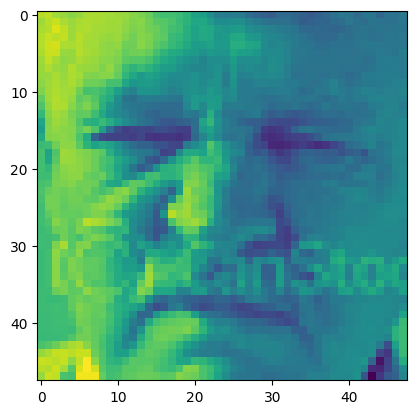

In [57]:
image="/content/emotion-detection-fer/train/disgusted/im100.png"
print("Orignal img is disgust")

img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("predicted emotion is ",pred_label)
plt.imshow(img.reshape(48,48))

In [58]:
from google.colab import files
files.download('emotion_detector.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>